In [1]:
import pprint

import ee
from IPython.display import Image

import openet.core.common as common
import openet.core.sharpen as sharpen

ee.Initialize(use_cloud_api=True)

In [2]:
def point_image_value(image, xy, scale=1):
    """Extract the output value from a calculation at a point"""
    return ee.Image(image).reduceRegion(
        reducer=ee.Reducer.first(), geometry=ee.Geometry.Point(xy),
        scale=scale).getInfo()

In [3]:
# landsat_id = 'LC08_044033_20170918'  # Cloudy, some clear areas over northern CV
# landsat_img = ee.Image('LANDSAT/LC08/C01/T1_TOA/{}'.format(landsat_id))
# pprint.pprint(landsat_img.getInfo()['properties'])
# pprint.pprint(ee.List(ee.String(ee.List(ee.String(landsat_img.get('system:id')).split('/')).get(-1)).split('_')).get(0).getInfo())
# Image(url=landsat_img.select([3, 2, 1])\
#           .getThumbURL({'min': 0.0, 'max': 3000, 'dimensions':512}), 
#       embed=True, format='png')

In [4]:
# landsat_id = 'LC08_044033_20170918'  # Cloudy, some clear areas over northern CV
landsat_id = 'LC08_044033_20170716'  # Clear
landsat_img = ee.Image('LANDSAT/LC08/C01/T1_SR/{}'.format(landsat_id))
# pprint.pprint(landsat_img.getInfo())
# pprint.pprint(landsat_img.get('system:id').getInfo())

In [5]:
study_geom = ee.Geometry.Rectangle(-121.75, 38.80, -121.6, 38.90)
study_region = study_geom.bounds(1, 'EPSG:4326')

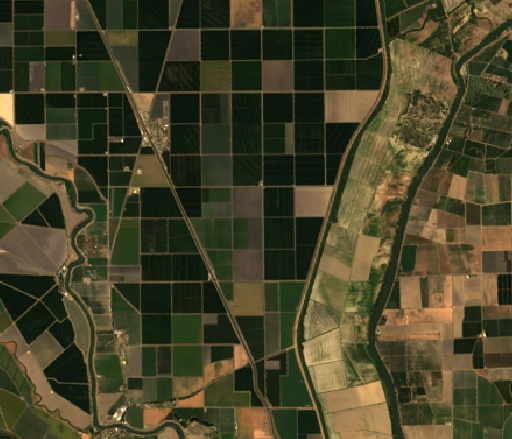

In [6]:
Image(url=landsat_img.select([3, 2, 1])\
          .getThumbURL({'min': 0.0, 'max': 3000, 'dimensions':512, 'region': study_region}), 
      embed=True, format='png')

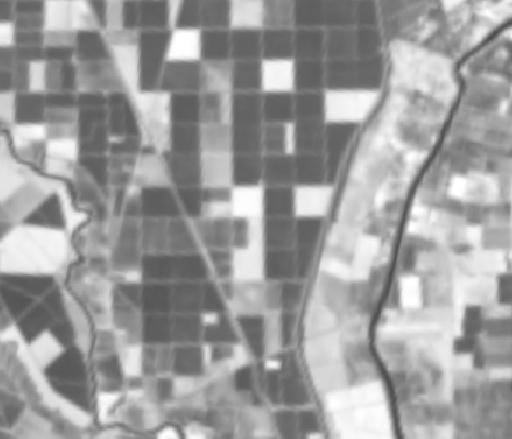

In [7]:
Image(url=landsat_img.select(['B10'])\
          .getThumbURL({'min': 2900, 'max': 3200, 'dimensions':512, 'region': study_region}), 
      embed=True, format='png')

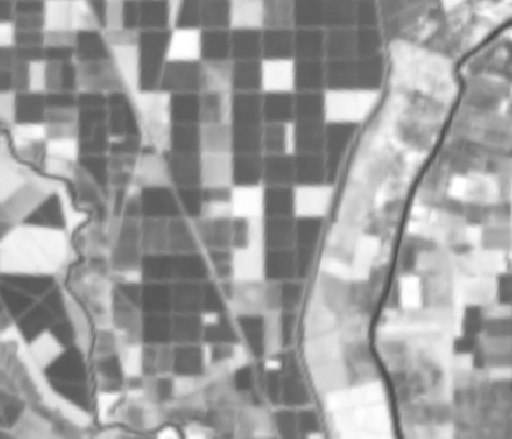

In [8]:
# Copied from PTJPL Image.from_landsat_c1_sr()
input_bands = ee.Dictionary({
    'LANDSAT_5': ['B1', 'B2', 'B3', 'B4', 'B5', 'B7', 'B6', 'pixel_qa'],
    'LANDSAT_7': ['B1', 'B2', 'B3', 'B4', 'B5', 'B7', 'B6', 'pixel_qa'],
    'LANDSAT_8': ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B10', 'pixel_qa']})
output_bands = ['blue', 'green', 'red', 'nir', 'swir1', 'swir2', 'tir',
                'pixel_qa']
spacecraft_id = ee.String(landsat_img.get('SATELLITE'))
prep_image = landsat_img \
    .select(input_bands.get(spacecraft_id), output_bands) \
    .multiply([0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.1, 1]) \
    .set({'system:index': landsat_img.get('system:index'),
          'system:time_start': landsat_img.get('system:time_start'),
          'system:id': landsat_img.get('system:id'), 
          'SATELLITE': landsat_img.get('SATELLITE')})
#     .copyProperties(landsat_img)
# pprint.pprint(prep_image.getInfo())

Image(url=prep_image.select(['tir'])\
          .getThumbURL({'min': 290, 'max': 320, 'dimensions':512, 'region': study_region}), 
      embed=True, format='png')

{'bands': [{'crs': 'EPSG:32610',
            'crs_transform': [30, 0, 501585, 0, -30, 4423515],
            'data_type': {'precision': 'double', 'type': 'PixelType'},
            'dimensions': [7661, 7791],
            'id': 'tir'}],
 'id': 'LANDSAT/LC08/C01/T1_SR/LC08_044033_20170716',
 'properties': {'SATELLITE': 'LANDSAT_8',
                'system:index': 'LC08_044033_20170716',
                'system:time_start': 1500230731093},
 'type': 'Image'}
'https://earthengine.googleapis.com/v1alpha/projects/earthengine-legacy/thumbnails/c5ea9156702ac4bcd05406e337878e00-5ed5440acb720894d5fecb2f7a747033:getPixels'


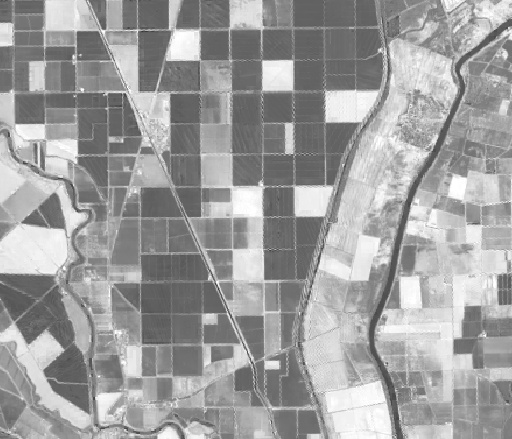

In [9]:
output_img = sharpen.thermal(prep_image)

pprint.pprint(output_img.select(['tir']).getInfo())
# pprint.pprint(point_image_value(output_img, [-121.5265, 38.7399], scale=1))

pprint.pprint(output_img.select(['tir'])\
          .getThumbURL({'min': 270, 'max': 310, 'dimensions':512}))

Image(url=output_img.select(['tir'])\
          .getThumbURL({'min': 290, 'max': 320, 'dimensions':512, 'region': study_region}), 
      embed=True, format='png')